In [ ]:
df['order_full_location'].value_counts()

order_full_location
Caribbean|Dominican Republic|Santo Domingo|Santo Domingo      223
East of USA|United States|New York|New York City              215
West of USA |United States|California|Los Angeles             148
Central America|Honduras|Francisco Morazan|Tegucigalpa        147
Western Europe|Austria|Vienna|Viena                           121
                                                             ... 
West Asia|Turkey|Hatay|Antakya                                  1
US Center |United States|Texas|Allen                            1
South of  USA |United States|Florida|Homestead                  1
Western Europe|France|Isle of France|Montereau-Fault-Yonne      1
US Center |United States|Kansas|Olathe                          1
Name: count, Length: 2755, dtype: int64

In [ ]:
def add_cyclical_features(df, col_name, max_val):
    """
    Add sine and cosine transformation for a cyclical column.
    max_val is the total number of distinct positions in the cycle 
    (e.g., 7 for day of week, 24 for hours, etc.).
    """
    df[col_name + "_sin"] = np.sin(2 * np.pi * df[col_name] / max_val)
    df[col_name + "_cos"] = np.cos(2 * np.pi * df[col_name] / max_val)
    return df

In [ ]:
colss = [
    "order_dayofweek", "shipping_dayofweek",
    "order_hour", "shipping_hour",
    "order_daynight", "ship_daynight",
    "order_daynight", "ship_daynight"
]

for col in colss:
    print(df[col].unique())

[2 1 6 3 5 0 4]
[0 4 5 1 6 2 3]
[17 23 13  3 14 12  1  7 22 11  5 16 18 19  2  6 20  0  4 10 21  9  8 15]
[17 23 13  3 14 12  1  7 22 11  5 16 18 19  2  6 20  0  4 10 21  9  8 15]
[3 4 2 5 0 1]
[3 4 2 5 0 1]
[3 4 2 5 0 1]
[3 4 2 5 0 1]


In [ ]:
# Apply cyclical feature transformation to train set
X_train_bal_org = add_cyclical_features(X_train_bal_org, "order_dayofweek", 7)
X_train_bal_org = add_cyclical_features(X_train_bal_org, "shipping_dayofweek", 7)
X_train_bal_org = add_cyclical_features(X_train_bal_org, "order_hour", 24)
X_train_bal_org = add_cyclical_features(X_train_bal_org, "shipping_hour", 24)
X_train_bal_org = add_cyclical_features(X_train_bal_org, "order_daynight", 6)  
X_train_bal_org = add_cyclical_features(X_train_bal_org, "ship_daynight", 6)  

# Apply the same transformation to test set
X_test_org = add_cyclical_features(X_test_org, "order_dayofweek", 7)
X_test_org = add_cyclical_features(X_test_org, "shipping_dayofweek", 7)
X_test_org = add_cyclical_features(X_test_org, "order_hour", 24)
X_test_org = add_cyclical_features(X_test_org, "shipping_hour", 24)
X_test_org = add_cyclical_features(X_test_org, "order_daynight", 6)  
X_test_org = add_cyclical_features(X_test_org, "ship_daynight", 6) 

In [ ]:
# 4️⃣ Drop the original categorical cyclical columns (optional)
X_train_bal_org = X_train_bal_org.drop(columns=[
    "order_dayofweek", "shipping_dayofweek",
    "order_hour", "shipping_hour",
    "order_daynight", "ship_daynight",
    "order_daynight", "ship_daynight"
])

X_test_org = X_test_org.drop(columns=[
    "order_dayofweek", "shipping_dayofweek",
    "order_hour", "shipping_hour",
    "order_daynight", "ship_daynight",
    "order_daynight", "ship_daynight"
])


In [ ]:
X_train_bal_org.head()

,payment_type,profit_per_order,category_name,customer_segment,market,order_item_discount,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,...,shipping_dayofweek_sin,shipping_dayofweek_cos,order_hour_sin,order_hour_cos,shipping_hour_sin,shipping_hour_cos,order_daynight_sin,order_daynight_cos,ship_daynight_sin,ship_daynight_cos
0,CASH,10.314638,Indoor/Outdoor Games,Home Office,LATAM,37.4850,49.98,0.050000,5.0,249.90,...,0.000000,1.000000,5.000000e-01,0.866025,5.000000e-01,0.866025,-0.866025,0.5,-0.866025,0.5
1,PAYMENT,-4.472153,Women's Apparel,Consumer,Europe,13.0000,50.00,0.052072,2.0,100.00,...,0.781831,0.623490,-7.071068e-01,0.707107,-7.071068e-01,0.707107,-0.866025,-0.5,-0.866025,-0.5
2,CASH,81.892784,Indoor/Outdoor Games,Consumer,LATAM,32.4870,49.98,0.330000,5.0,249.90,...,0.433884,-0.900969,1.224647e-16,-1.000000,1.224647e-16,-1.000000,0.866025,-0.5,0.866025,-0.5
3,DEBIT,134.113050,Camping & Hiking,Consumer,LATAM,47.9968,299.98,0.500000,1.0,299.98,...,-0.433884,-0.900969,2.588190e-01,0.965926,2.588190e-01,0.965926,-0.866025,0.5,-0.866025,0.5
4,CASH,22.352833,Cleats,Consumer,LATAM,29.9950,59.99,0.310000,2.0,119.98,...,0.974928,-0.222521,2.588190e-01,0.965926,2.588190e-01,0.965926,-0.866025,0.5,-0.866025,0.5


In [ ]:
agg_df = df.groupby('order_full_location')['label'].value_counts().unstack(fill_value=0).reset_index()

# Rename for clarity
agg_df.columns = ['order_full_location', 'early_count', 'on_time_count', 'delay_count']

# Total orders from that location
agg_df['order_count'] = agg_df[['early_count', 'on_time_count', 'delay_count']].sum(axis=1)

agg_df


,order_full_location,early_count,on_time_count,delay_count,order_count
0,Canada|Canada|Alberta|Calgary,2,2,3,7
1,Canada|Canada|Alberta|Edmonton,0,0,2,2
2,Canada|Canada|British Columbia|Saanich,0,0,2,2
3,Canada|Canada|Manitoba|Winnipeg,0,1,1,2
4,Canada|Canada|Nova Scotia|Dartmouth,0,0,1,1
...,...,...,...,...,...
2750,Western Europe|Switzerland|Geneva|Geneva,0,0,3,3
2751,Western Europe|Switzerland|Lucerne|Lucerna,0,1,0,1
2752,Western Europe|Switzerland|St. Gallen|St. Gallen,0,0,3,3
2753,Western Europe|Switzerland|Zurich|Winterthur,0,1,1,2


In [ ]:
agg_df['dominant_target'] = agg_df[['early_count', 'on_time_count', 'delay_count']].idxmax(axis=1)
agg_df

,order_full_location,early_count,on_time_count,delay_count,order_count,dominant_target
0,Canada|Canada|Alberta|Calgary,2,2,3,7,delay_count
1,Canada|Canada|Alberta|Edmonton,0,0,2,2,delay_count
2,Canada|Canada|British Columbia|Saanich,0,0,2,2,delay_count
3,Canada|Canada|Manitoba|Winnipeg,0,1,1,2,on_time_count
4,Canada|Canada|Nova Scotia|Dartmouth,0,0,1,1,delay_count
...,...,...,...,...,...,...
2750,Western Europe|Switzerland|Geneva|Geneva,0,0,3,3,delay_count
2751,Western Europe|Switzerland|Lucerne|Lucerna,0,1,0,1,on_time_count
2752,Western Europe|Switzerland|St. Gallen|St. Gallen,0,0,3,3,delay_count
2753,Western Europe|Switzerland|Zurich|Winterthur,0,1,1,2,on_time_count


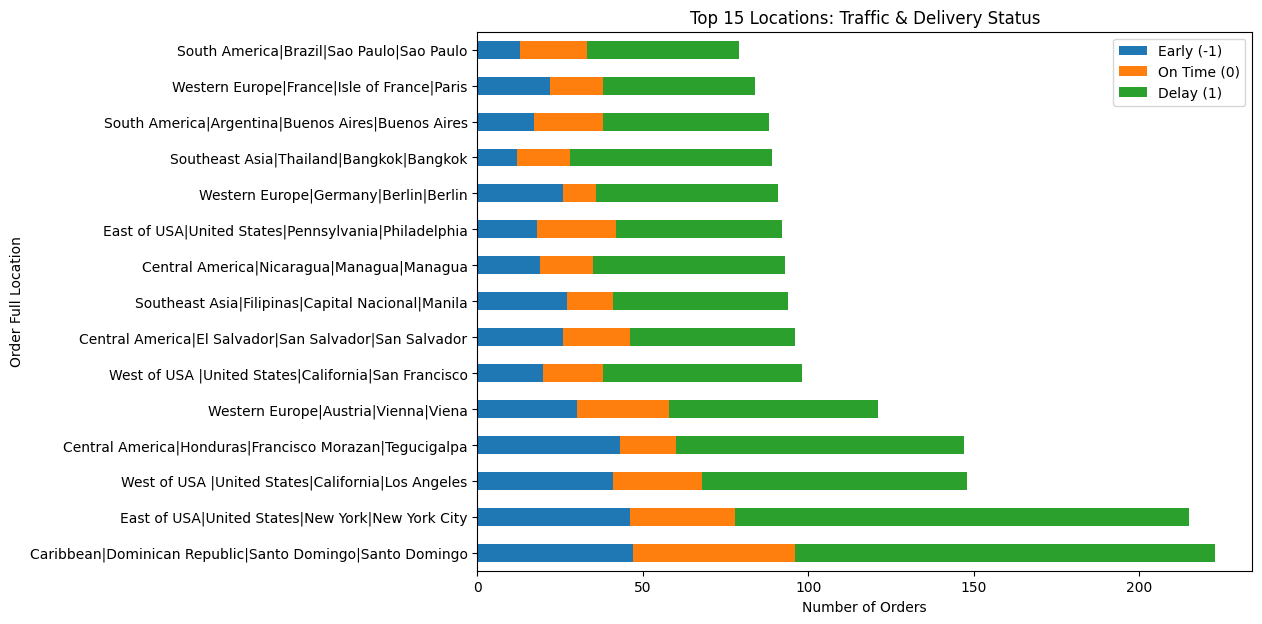

In [ ]:
import matplotlib.pyplot as plt

top_n = 15
top_locations = agg_df.sort_values('order_count', ascending=False).head(top_n)

# Stacked bar plot
top_locations.set_index('order_full_location')[['early_count', 'on_time_count', 'delay_count']].plot(
    kind='barh', stacked=True, figsize=(10,7)
)

plt.xlabel("Number of Orders")
plt.ylabel("Order Full Location")
plt.title(f"Top {top_n} Locations: Traffic & Delivery Status")
plt.legend(["Early (-1)", "On Time (0)", "Delay (1)"])
plt.show()

In [ ]:
agg_df['traffic_bin'] = pd.qcut(
    agg_df['order_count'], q=3, labels=['Low Traffic', 'Mid Traffic', 'High Traffic']
)
agg_df

,order_full_location,early_count,on_time_count,delay_count,order_count,dominant_target,traffic_bin
0,Canada|Canada|Alberta|Calgary,2,2,3,7,delay_count,High Traffic
1,Canada|Canada|Alberta|Edmonton,0,0,2,2,delay_count,Low Traffic
2,Canada|Canada|British Columbia|Saanich,0,0,2,2,delay_count,Low Traffic
3,Canada|Canada|Manitoba|Winnipeg,0,1,1,2,on_time_count,Low Traffic
4,Canada|Canada|Nova Scotia|Dartmouth,0,0,1,1,delay_count,Low Traffic
...,...,...,...,...,...,...,...
2750,Western Europe|Switzerland|Geneva|Geneva,0,0,3,3,delay_count,Mid Traffic
2751,Western Europe|Switzerland|Lucerne|Lucerna,0,1,0,1,on_time_count,Low Traffic
2752,Western Europe|Switzerland|St. Gallen|St. Gallen,0,0,3,3,delay_count,Mid Traffic
2753,Western Europe|Switzerland|Zurich|Winterthur,0,1,1,2,on_time_count,Low Traffic


In [ ]:
df_grouped = df.groupby('order_full_location').agg(
    order_count=('label', 'size'),  # count number of rows in each group
    delay_pct=('label', lambda x: (x == 1).mean() * 100),
    early_pct=('label', lambda x: (x == -1).mean() * 100),
    ontime_pct=('label', lambda x: (x == 0).mean() * 100)
).reset_index()

df_grouped

,order_full_location,order_count,delay_pct,early_pct,ontime_pct
0,Canada|Canada|Alberta|Calgary,7,42.857143,28.571429,28.571429
1,Canada|Canada|Alberta|Edmonton,2,100.000000,0.000000,0.000000
2,Canada|Canada|British Columbia|Saanich,2,100.000000,0.000000,0.000000
3,Canada|Canada|Manitoba|Winnipeg,2,50.000000,0.000000,50.000000
4,Canada|Canada|Nova Scotia|Dartmouth,1,100.000000,0.000000,0.000000
...,...,...,...,...,...
2750,Western Europe|Switzerland|Geneva|Geneva,3,100.000000,0.000000,0.000000
2751,Western Europe|Switzerland|Lucerne|Lucerna,1,0.000000,0.000000,100.000000
2752,Western Europe|Switzerland|St. Gallen|St. Gallen,3,100.000000,0.000000,0.000000
2753,Western Europe|Switzerland|Zurich|Winterthur,2,50.000000,0.000000,50.000000


In [ ]:
# Example traffic categories by count
df_grouped['traffic_category'] = pd.qcut(
    df_grouped['order_count'], 
    q=3, 
    labels=['Low Traffic', 'Mid Traffic', 'High Traffic']
)

df_grouped

,order_full_location,order_count,delay_pct,early_pct,ontime_pct,traffic_category
0,Canada|Canada|Alberta|Calgary,7,42.857143,28.571429,28.571429,High Traffic
1,Canada|Canada|Alberta|Edmonton,2,100.000000,0.000000,0.000000,Low Traffic
2,Canada|Canada|British Columbia|Saanich,2,100.000000,0.000000,0.000000,Low Traffic
3,Canada|Canada|Manitoba|Winnipeg,2,50.000000,0.000000,50.000000,Low Traffic
4,Canada|Canada|Nova Scotia|Dartmouth,1,100.000000,0.000000,0.000000,Low Traffic
...,...,...,...,...,...,...
2750,Western Europe|Switzerland|Geneva|Geneva,3,100.000000,0.000000,0.000000,Mid Traffic
2751,Western Europe|Switzerland|Lucerne|Lucerna,1,0.000000,0.000000,100.000000,Low Traffic
2752,Western Europe|Switzerland|St. Gallen|St. Gallen,3,100.000000,0.000000,0.000000,Mid Traffic
2753,Western Europe|Switzerland|Zurich|Winterthur,2,50.000000,0.000000,50.000000,Low Traffic


In [ ]:
# Example performance categories by delay %
df_grouped['performance_category'] = pd.cut(
    df_grouped['delay_pct'],
    bins=[-1, 33, 66, 100],
    labels=['Low Delay', 'Medium Delay', 'High Delay']
)

df_grouped

,order_full_location,order_count,delay_pct,early_pct,ontime_pct,traffic_category,performance_category
0,Canada|Canada|Alberta|Calgary,7,42.857143,28.571429,28.571429,High Traffic,Medium Delay
1,Canada|Canada|Alberta|Edmonton,2,100.000000,0.000000,0.000000,Low Traffic,High Delay
2,Canada|Canada|British Columbia|Saanich,2,100.000000,0.000000,0.000000,Low Traffic,High Delay
3,Canada|Canada|Manitoba|Winnipeg,2,50.000000,0.000000,50.000000,Low Traffic,Medium Delay
4,Canada|Canada|Nova Scotia|Dartmouth,1,100.000000,0.000000,0.000000,Low Traffic,High Delay
...,...,...,...,...,...,...,...
2750,Western Europe|Switzerland|Geneva|Geneva,3,100.000000,0.000000,0.000000,Mid Traffic,High Delay
2751,Western Europe|Switzerland|Lucerne|Lucerna,1,0.000000,0.000000,100.000000,Low Traffic,Low Delay
2752,Western Europe|Switzerland|St. Gallen|St. Gallen,3,100.000000,0.000000,0.000000,Mid Traffic,High Delay
2753,Western Europe|Switzerland|Zurich|Winterthur,2,50.000000,0.000000,50.000000,Low Traffic,Medium Delay


In [ ]:
w_delay = 1.0
w_early = 0.5
w_ontime = 1.0

df_grouped['performance_score'] = (
    w_delay * df_grouped['delay_pct'] +
    w_early * df_grouped['early_pct'] -
    w_ontime * df_grouped['ontime_pct']
)

# Now bin based on this score
df_grouped['performance_category2'] = pd.cut(
    df_grouped['performance_score'],
    bins=[-101, -75, -25, 25, 75, 100],  # adjust based on your data range
    labels=['very low delay', 'low delay', 'medium delay', 'high delay', 'extreme delay']
)

df_grouped

,order_full_location,order_count,delay_pct,early_pct,ontime_pct,traffic_category,performance_category,performance_score,performance_category2
0,Canada|Canada|Alberta|Calgary,7,42.857143,28.571429,28.571429,High Traffic,Medium Delay,28.571429,high delay
1,Canada|Canada|Alberta|Edmonton,2,100.000000,0.000000,0.000000,Low Traffic,High Delay,100.000000,extreme delay
2,Canada|Canada|British Columbia|Saanich,2,100.000000,0.000000,0.000000,Low Traffic,High Delay,100.000000,extreme delay
3,Canada|Canada|Manitoba|Winnipeg,2,50.000000,0.000000,50.000000,Low Traffic,Medium Delay,0.000000,medium delay
4,Canada|Canada|Nova Scotia|Dartmouth,1,100.000000,0.000000,0.000000,Low Traffic,High Delay,100.000000,extreme delay
...,...,...,...,...,...,...,...,...,...
2750,Western Europe|Switzerland|Geneva|Geneva,3,100.000000,0.000000,0.000000,Mid Traffic,High Delay,100.000000,extreme delay
2751,Western Europe|Switzerland|Lucerne|Lucerna,1,0.000000,0.000000,100.000000,Low Traffic,Low Delay,-100.000000,very low delay
2752,Western Europe|Switzerland|St. Gallen|St. Gallen,3,100.000000,0.000000,0.000000,Mid Traffic,High Delay,100.000000,extreme delay
2753,Western Europe|Switzerland|Zurich|Winterthur,2,50.000000,0.000000,50.000000,Low Traffic,Medium Delay,0.000000,medium delay


In [ ]:
# Step 4: Merge back to original df
df = df.merge(
    df_grouped[['order_full_location', 'performance_score', 'performance_category2']],
    on='order_full_location',
    how='left'
)

In [ ]:
# Create a contingency table of counts: performance_category2 vs label
contingency_table = pd.crosstab(df['performance_category2'], df['label'])

print("Contingency Table:")
print(contingency_table)

# Perform Chi-square test of independence
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4e}")

if p < 0.05:
    print("Result: Significant association between performance_category2 and label.")
else:
    print("Result: No significant association between performance_category2 and label.")


Contingency Table:
label                    -1     0     1
performance_category2                  
very low delay            0   174     0
low delay                79   163    31
medium delay            409   743   725
high delay             2832  1832  5865
extreme delay           394    13  2288

Chi-square statistic: 2637.5104
Degrees of freedom: 8
p-value: 0.0000e+00
Result: Significant association between performance_category2 and label.


In [ ]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df['performance_score'], df['label'])

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df['performance_score'], df['label'])

print(f"Pearson correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4e}")
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")

Pearson correlation: 0.1940, p-value: 1.1530e-131
Spearman correlation: 0.2255, p-value: 1.9364e-178


In [ ]:
df_grouped1 = df.groupby('customer_full_location').agg(
    order_count=('label', 'size'),  # count number of rows in each group
    delay_pct=('label', lambda x: (x == 1).mean() * 100),
    early_pct=('label', lambda x: (x == -1).mean() * 100),
    ontime_pct=('label', lambda x: (x == 0).mean() * 100)
).reset_index()

df_grouped1

,customer_full_location,order_count,delay_pct,early_pct,ontime_pct
0,EE. UU.|95758|CA,2,0.000000,50.000000,50.000000
1,EE. UU.|AL|Birmingham,12,58.333333,16.666667,25.000000
2,EE. UU.|AR|Conway,5,20.000000,40.000000,40.000000
3,EE. UU.|AR|Jonesboro,5,80.000000,20.000000,0.000000
4,EE. UU.|AZ|Chandler,17,58.823529,23.529412,17.647059
...,...,...,...,...,...
553,Puerto Rico|PR|Toa Alta,3,33.333333,33.333333,33.333333
554,Puerto Rico|PR|Toa Baja,6,33.333333,50.000000,16.666667
555,Puerto Rico|PR|Trujillo Alto,6,50.000000,33.333333,16.666667
556,Puerto Rico|PR|Vega Baja,11,63.636364,18.181818,18.181818


In [ ]:
w_delay = 1.0
w_early = 0.5
w_ontime = 1.0

df_grouped1['performance_score2'] = (
    w_delay * df_grouped1['delay_pct'] +
    w_early * df_grouped1['early_pct'] -
    w_ontime * df_grouped1['ontime_pct']
)

# Now bin based on this score
df_grouped1['performance_category3'] = pd.cut(
    df_grouped1['performance_score2'],
    bins=[-101, -75, -25, 25, 75, 100],  # adjust based on your data range
    labels=['very low delay', 'low delay', 'medium delay', 'high delay', 'extreme delay']
)

df_grouped1

,customer_full_location,order_count,delay_pct,early_pct,ontime_pct,performance_score2,performance_category3
0,EE. UU.|95758|CA,2,0.000000,50.000000,50.000000,-25.000000,low delay
1,EE. UU.|AL|Birmingham,12,58.333333,16.666667,25.000000,41.666667,high delay
2,EE. UU.|AR|Conway,5,20.000000,40.000000,40.000000,0.000000,medium delay
3,EE. UU.|AR|Jonesboro,5,80.000000,20.000000,0.000000,90.000000,extreme delay
4,EE. UU.|AZ|Chandler,17,58.823529,23.529412,17.647059,52.941176,high delay
...,...,...,...,...,...,...,...
553,Puerto Rico|PR|Toa Alta,3,33.333333,33.333333,33.333333,16.666667,medium delay
554,Puerto Rico|PR|Toa Baja,6,33.333333,50.000000,16.666667,41.666667,high delay
555,Puerto Rico|PR|Trujillo Alto,6,50.000000,33.333333,16.666667,50.000000,high delay
556,Puerto Rico|PR|Vega Baja,11,63.636364,18.181818,18.181818,54.545455,high delay


In [ ]:
# Step 4: Merge back to original df
df = df.merge(
    df_grouped1[['customer_full_location', 'performance_score2', 'performance_category3']],
    on='customer_full_location',
    how='left'
)

In [ ]:
df[['customer_full_location', 'performance_score2', 'performance_category3']]

,customer_full_location,performance_score2,performance_category3
0,EE. UU.|CT|Milford,47.857143,high delay
1,Puerto Rico|PR|Caguas,48.733738,high delay
2,Puerto Rico|PR|Caguas,48.733738,high delay
3,Puerto Rico|PR|Caguas,48.733738,high delay
4,Puerto Rico|PR|Caguas,48.733738,high delay
...,...,...,...
15543,EE. UU.|MI|Detroit,47.647059,high delay
15544,EE. UU.|TX|Eagle Pass,35.714286,high delay
15545,Puerto Rico|PR|Caguas,48.733738,high delay
15546,EE. UU.|OH|Reynoldsburg,78.571429,extreme delay


In [ ]:
import scipy.stats as stats

# Prepare data groups based on label
group_early = df[df['label'] == -1]['performance_score2'].dropna()
group_ontime = df[df['label'] == 0]['performance_score2'].dropna()
group_delay = df[df['label'] == 1]['performance_score2'].dropna()

# Perform one-way ANOVA
f_stat, p_value = stats.f_oneway(group_early, group_ontime, group_delay)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Result: Statistically significant difference in performance_score across label groups.")
else:
    print("Result: No statistically significant difference in performance_score across label groups.")

ANOVA F-statistic: 289.8970
ANOVA p-value: 2.4572e-124
Result: Statistically significant difference in performance_score across label groups.


In [ ]:
# Create a contingency table of counts: performance_category2 vs label
contingency_table = pd.crosstab(df['performance_category3'], df['label'])

print("Contingency Table:")
print(contingency_table)

# Perform Chi-square test of independence
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4e}")

if p < 0.05:
    print("Result: Significant association between performance_category2 and label.")
else:
    print("Result: No significant association between performance_category2 and label.")

Contingency Table:
label                    -1     0     1
performance_category3                  
very low delay            0     2     0
low delay                 5    13     3
medium delay            154   276   296
high delay             3405  2623  8046
extreme delay           150    11   564

Chi-square statistic: 387.5930
Degrees of freedom: 8
p-value: 8.4311e-79
Result: Significant association between performance_category2 and label.


In [ ]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df['performance_score2'], df['label'])

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df['performance_score2'], df['label'])

print(f"Pearson correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4e}")
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")

Pearson correlation: 0.0868, p-value: 2.0279e-27
Spearman correlation: 0.0893, p-value: 6.7941e-29


In [ ]:
df.columns

Index(['payment_type', 'profit_per_order', 'category_name', 'customer_segment',
       'market', 'order_city', 'order_country', 'order_item_discount',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_profit_per_order',
       'order_region', 'order_state', 'product_name', 'shipping_mode', 'label',
       'distance_normalized', 'customer_country', 'customer_city',
       'customer_state', 'order_to_shipment_days', 'order_dayofweek',
       'shipping_dayofweek', 'order_hour', 'shipping_hour',
       'order_shipping_time', 'order_daynight', 'ship_daynight',
       'order_to_shipment_planned_days', 'shipment_delay_days',
       'order_full_location', 'customer_full_location', 'performance_score',
       'performance_category2', 'performance_score2', 'performance_category3'],
      dtype='object')